Загружено логов: 28

Активность IP:
src_ip
192.168.1.10     5
185.220.101.1    5
203.0.113.45     4
45.33.32.156     4
10.0.0.15        3
192.168.1.40     3
192.168.1.20     2
192.168.1.30     2
Name: count, dtype: int64

Подозрительные IP:
['192.168.1.10', '185.220.101.1', '203.0.113.45', '45.33.32.156']

Проверка IP 192.168.1.10 через VirusTotal...

Проверка IP 185.220.101.1 через VirusTotal...

Проверка IP 203.0.113.45 через VirusTotal...

Проверка IP 45.33.32.156 через VirusTotal...

VirusTotal результаты:
{'192.168.1.10': 0, '185.220.101.1': 18, '203.0.113.45': 0, '45.33.32.156': 5}
⚠️ Угроза обнаружена: 185.220.101.1
🚫 Имитация блокировки IP 185.220.101.1
⚠️ Угроза обнаружена: 45.33.32.156
🚫 Имитация блокировки IP 45.33.32.156

Обнаруженные атаки:
           src_ip                 signature
12  185.220.101.1  Possible SSH brute force
13  185.220.101.1  Possible SSH brute force
14  185.220.101.1  Possible SSH brute force
15  185.220.101.1  Possible SSH brute force
16  185.220.101.

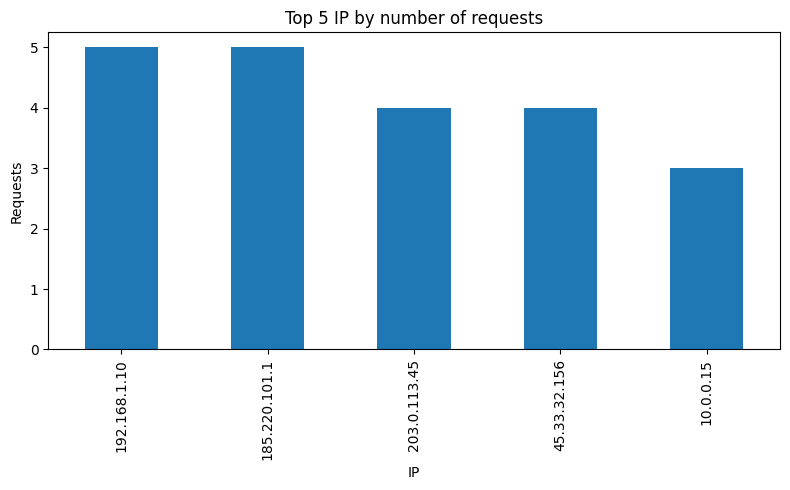

In [7]:
from dotenv import load_dotenv
import os
import requests
import pandas as pd
import json
import matplotlib.pyplot as plt

# -----------------------------
# Загрузка переменных окружения
# -----------------------------

load_dotenv()

VT_API_KEY = os.getenv("VT_API_KEY")

if not VT_API_KEY:
    print("Ошибка: API ключ VirusTotal не найден. Проверь файл .env")
    exit()

# -----------------------------
# Подготовка папок
# -----------------------------

os.makedirs("reports", exist_ok=True)

# -----------------------------
# 1. Загрузка логов Suricata
# -----------------------------

with open("data/suricata_logs.json") as f:
    logs = json.load(f)

df = pd.DataFrame(logs)

print("Загружено логов:", len(df))

# -----------------------------
# 2. Анализ логов
# -----------------------------

ip_counts = df["src_ip"].value_counts()

print("\nАктивность IP:")
print(ip_counts)

# подозрительный IP если >3 запросов
suspicious_ips = ip_counts[ip_counts > 3].index.tolist()

print("\nПодозрительные IP:")
print(suspicious_ips)

# -----------------------------
# 3. Проверка IP через VirusTotal
# -----------------------------

def check_ip_virustotal(ip):

    url = f"https://www.virustotal.com/api/v3/ip_addresses/{ip}"

    headers = {
        "x-apikey": VT_API_KEY
    }

    response = requests.get(url, headers=headers)

    if response.status_code != 200:
        return None

    data = response.json()

    stats = data["data"]["attributes"]["last_analysis_stats"]

    malicious = stats["malicious"]
    suspicious = stats["suspicious"]

    return malicious + suspicious


vt_results = {}

for ip in suspicious_ips:

    print(f"\nПроверка IP {ip} через VirusTotal...")

    result = check_ip_virustotal(ip)

    if result is not None:
        vt_results[ip] = result
    else:
        vt_results[ip] = 0

print("\nVirusTotal результаты:")
print(vt_results)

# -----------------------------
# 4. Реагирование
# -----------------------------

blocked_ips = []

for ip, score in vt_results.items():

    if score > 0:
        print(f"⚠️ Угроза обнаружена: {ip}")
        print(f"🚫 Имитация блокировки IP {ip}")

        blocked_ips.append(ip)

alerts = df[df["event_type"] == "alert"]

print("\nОбнаруженные атаки:")

if not alerts.empty:
    print(alerts[["src_ip","signature"]])

# -----------------------------
# 5. Создание отчета
# -----------------------------

report = pd.DataFrame({
    "ip": list(ip_counts.index),
    "requests": list(ip_counts.values)
})

report["blocked"] = report["ip"].apply(lambda x: x in blocked_ips)

report.to_csv("reports/threat_report.csv", index=False)

print("\nОтчет сохранен: reports/threat_report.csv")

# -----------------------------
# 6. Построение графика
# -----------------------------

plt.figure(figsize=(8,5))

ip_counts.head(5).plot(kind="bar")

plt.title("Top 5 IP by number of requests")
plt.xlabel("IP")
plt.ylabel("Requests")

plt.tight_layout()

plt.savefig("reports/threat_graph.png")

print("График сохранен: reports/threat_graph.png")